# Résolution du Problème NP-Difficile de Kemeny

Goales Saphiya et Teibi Zahra  

Dans ce notebook, nous présentons les différentes fonctions permettant de résoudre le problème de Kemeny.

### 1. Résolution d'instances réelles 

Dans cette première partie, nous utiliserons le profil de préférences suivant.

| Nombre de votants | Ordre de préférence |
| :--- | :--- |
| 2 | a > c > f > e > d > b |
| 1 | a > c > e > f > d > b |
| 2 | a > d > c > f > e > b |
| 1 | a > b > d > c > f > e |
| 2 | a > b > f > e > d > c |

D'abord, nous lisons cette instance à partir d'un fichier .soc à l'aide de la bibliothèque OrdinalInstance de preflibtools.instances. On associe chaque lettre à son rang dans l’alphabet. 


In [10]:
import instance as inst
i = inst.Instance()
i.lecture_fichier('exemple.soc')

4.4862000001089086e-05

Notre instance est maintenant stockée dans l'objet i. Afin de la visualiser et d'appliquer le critère de Condorcet étendu, on peut construire et afficher son graphe de majorité.  

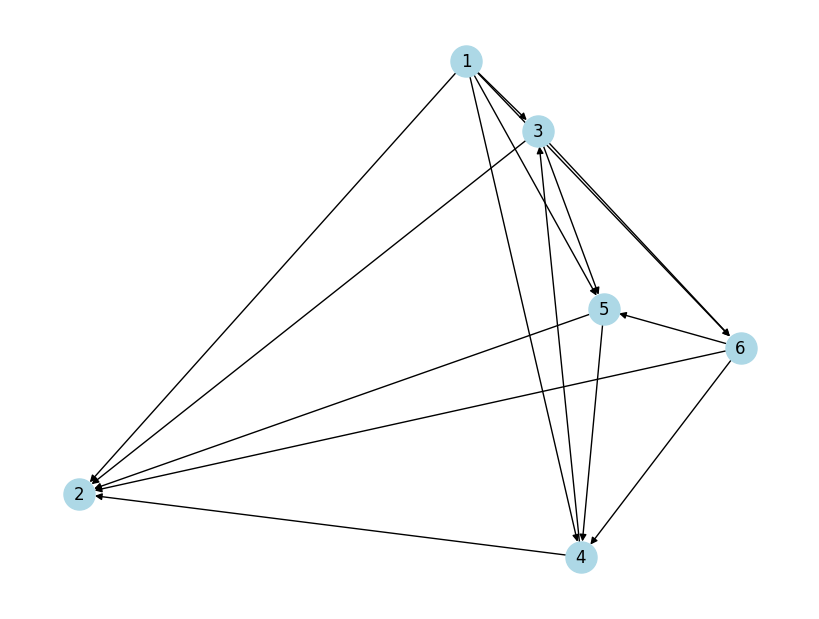

In [11]:
i.construction_graphe_majorite()
i.graphe.afficher_graphe()

Nous allons maintenant tester nos méthodes de réduction sur cette instance.

In [12]:
classement_trois_quart = inst.majorite_trois_quart(i)
print("Réduction à l'aide de la règle de majorité des 3/4 :\n",classement_trois_quart)

classement_CCE = inst.condorcet_etendu(i)
print("\nRéduction à l'aide du critère de Condorcet étendu :\n",classement_CCE)

Réduction à l'aide de la règle de majorité des 3/4 :
 [<instance.Instance object at 0x7f63c4284790>, 1, <instance.Instance object at 0x7f63c42b7c10>]

Réduction à l'aide du critère de Condorcet étendu :
 [1, <instance.Instance object at 0x7f63c42ca460>, 2]


Pour tester nos fonctions de résolution, nous allons résoudre la sous instance obtenue après réduction par le critère de Condorcet étendu.

In [13]:
sous_inst = classement_CCE[1]

result_PL = inst.resolution_pl(sous_inst) 
print("Résolution de la sous instance avec la programmation dynamique \n" , inst.reconstruction_classement_PL(result_PL,sous_inst))

result_PDyn = inst.resolution_dyn(sous_inst) 
print("\nRésolution de la sous instance avec la programmation linéaire \n",inst.reconstruction_classement_PDyn(result_PDyn,sous_inst))

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Debian GNU/Linux 13 (trixie)")

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 24 logical processors, using up to 24 threads

Academic license 2782231 - for non-commercial use only - registered to sa___@etu.sorbonne-universite.fr
Optimize a model with 14 rows, 12 columns and 36 nonzeros
Model fingerprint: 0xd1eb9fcf
Variable types: 0 continuous, 12 integer (12 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 7e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 26.0000000
Presolve removed 6 rows and 6 columns
Presolve time: 0.00s
Presolved: 8 rows, 6 columns, 24 nonzeros
Variable types: 0 continuous, 6 integer (6 binary)

Root relaxation: objective 1.600000e+01, 0 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bound

Afin d'automatiser le processus, nous avons implémenté une fonction permettant d'appliquer ou non une méthode de décomposition (ou les deux) et de résoudre l'instance.

Nous allons d'abord tester la programmation linéaire.

In [14]:
res = inst.resolution(i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=None, reduction2=None)
print("Résolution de l'instance avec la programmation linéaire sans réduction : \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.majorite_trois_quart, reduction2=None)
print("\nRésolution de l'instance avec la programmation linéaire avec 3/4 :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.condorcet_etendu, reduction2=None)
print("\nRésolution de l'instance avec la programmation linéaire avec CCE :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.condorcet_etendu, reduction2=inst.majorite_trois_quart)
print("\nRésolution de l'instance avec la programmation linéaire avec CCE puis 3/4 : \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.majorite_trois_quart, reduction2=inst.condorcet_etendu)
print("\nRésolution de l'instance avec la programmation linéaire avec 3/4 puis CCE : \n temps de résolution : " , res[0] , "\n classement : ", res[1])


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Debian GNU/Linux 13 (trixie)")

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 24 logical processors, using up to 24 threads

Academic license 2782231 - for non-commercial use only - registered to sa___@etu.sorbonne-universite.fr
Optimize a model with 55 rows, 30 columns and 150 nonzeros
Model fingerprint: 0xdf0ed9d0
Variable types: 0 continuous, 30 integer (30 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 8e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 66.0000000
Presolve removed 15 rows and 15 columns
Presolve time: 0.00s
Presolved: 40 rows, 15 columns, 120 nonzeros
Variable types: 0 continuous, 15 integer (15 binary)
Found heuristic solution: objective 50.0000000

Root relaxation: objective 2.800000e+01, 0 iterations, 0.00 seconds (0.00 work units)



Puis, nous testons la programmation dynamique.

In [15]:
res = inst.resolution(i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=None, reduction2=None)
print("Résolution de l'instance avec la programmation dynamique sans réduction \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.majorite_trois_quart, reduction2=None)
print("\nRésolution de l'instance avec la programmation dynamique avec 3/4 :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.condorcet_etendu, reduction2=None)
print("\nRésolution de l'instance avec la programmation dynamique avec CCE :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.condorcet_etendu, reduction2=inst.majorite_trois_quart)
print("\nRésolution de l'instance avec la programmation dynamique avec CCE puis 3/4 : \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.majorite_trois_quart, reduction2=inst.condorcet_etendu)
print("\nRésolution de l'instance avec la programmation dynamique avec 3/4 puis CCE : \n temps de résolution : " , res[0] , "\n classement : ", res[1])



candidats :  (1,)
candidats :  (2,)
candidats :  (3,)
candidats :  (4,)
candidats :  (5,)
candidats :  (6,)
candidats :  (1, 2)
candidats :  (1, 3)
candidats :  (1, 4)
candidats :  (1, 5)
candidats :  (1, 6)
candidats :  (2, 3)
candidats :  (2, 4)
candidats :  (2, 5)
candidats :  (2, 6)
candidats :  (3, 4)
candidats :  (3, 5)
candidats :  (3, 6)
candidats :  (4, 5)
candidats :  (4, 6)
candidats :  (5, 6)
candidats :  (1, 2, 3)
candidats :  (1, 2, 4)
candidats :  (1, 2, 5)
candidats :  (1, 2, 6)
candidats :  (1, 3, 4)
candidats :  (1, 3, 5)
candidats :  (1, 3, 6)
candidats :  (1, 4, 5)
candidats :  (1, 4, 6)
candidats :  (1, 5, 6)
candidats :  (2, 3, 4)
candidats :  (2, 3, 5)
candidats :  (2, 3, 6)
candidats :  (2, 4, 5)
candidats :  (2, 4, 6)
candidats :  (2, 5, 6)
candidats :  (3, 4, 5)
candidats :  (3, 4, 6)
candidats :  (3, 5, 6)
candidats :  (4, 5, 6)
candidats :  (1, 2, 3, 4)
candidats :  (1, 2, 3, 5)
candidats :  (1, 2, 3, 6)
candidats :  (1, 2, 4, 5)
candidats :  (1, 2, 4, 6)
ca

### 2. Résolution d'instances générées (modèle de Mallows)

Dans cette deuxième partie, nous utilisons le modèle de Mallows pour générer des instances. Le code pour travailler avec le modèle de Mallows est issu de github : https://github.com/ekhiru/top-k-mallows.

In [16]:
import numpy as np
import sys
sys.path.append("top-k-mallows")
import mallows_kendall as mk

n=6
m=10
s0 = np.arange(0,n)
profil_preferences = mk.sample(m=m, n=n, theta=0.5, s0=s0)
print('profil de preference : \n', profil_preferences)

nv_i = inst.Instance()

nv_i.nb_candidats = n
nv_i.nb_votants = m 

nv_i.candidats = {}
for j in range(n):
    nv_i.candidats[j+1] = str(j+1) 

nv_i.matPref = np.zeros((n+1,n+1))

for pref in profil_preferences:
    # On parcourt toutes les paires de POSITIONS (k, j)
    for k in range(1,n+1): 
        for j in range(k + 1, n+1): 
            # Le candidat à la position k est préféré au candidat à la position j
            nv_i.matPref[pref[k-1]+1, pref[j-1]+1] += 1
nv_i.init = True



profil de preference : 
 [[1 0 2 5 3 4]
 [0 2 5 3 4 1]
 [0 1 4 5 3 2]
 [0 2 1 3 5 4]
 [4 1 0 2 3 5]
 [3 4 0 2 1 5]
 [0 5 1 2 3 4]
 [0 3 4 2 5 1]
 [0 2 1 3 5 4]
 [0 2 3 5 1 4]]


Nous pouvons ensuite résoudre l'instance générée avec et sans réduction et avec nos deux méthodes de résolution, en appelant la même fonction que précédement. 

In [17]:
res = inst.resolution(nv_i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=None, reduction2=None)
print("Résolution de l'instance avec la programmation linéaire sans réduction : \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.majorite_trois_quart, reduction2=None)
print("\nRésolution de l'instance avec la programmation linéaire avec 3/4 :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.condorcet_etendu, reduction2=None)
print("\nRésolution de l'instance avec la programmation linéaire avec CCE :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.condorcet_etendu, reduction2=inst.majorite_trois_quart)
print("\nRésolution de l'instance avec la programmation linéaire avec CCE puis 3/4 : \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.majorite_trois_quart, reduction2=inst.condorcet_etendu)
print("\nRésolution de l'instance avec la programmation linéaire avec 3/4 puis CCE : \n temps de résolution : " , res[0] , "\n classement : ", res[1])


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Debian GNU/Linux 13 (trixie)")

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 24 logical processors, using up to 24 threads

Academic license 2782231 - for non-commercial use only - registered to sa___@etu.sorbonne-universite.fr
Optimize a model with 55 rows, 30 columns and 150 nonzeros
Model fingerprint: 0xdd098400
Variable types: 0 continuous, 30 integer (30 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 72.0000000
Presolve removed 15 rows and 15 columns
Presolve time: 0.00s
Presolved: 40 rows, 15 columns, 120 nonzeros
Variable types: 0 continuous, 15 integer (15 binary)
Found heuristic solution: objective 58.0000000

Root relaxation: objective 4.000000e+01, 0 iterations, 0.00 seconds (0.00 work units)



In [18]:
res = inst.resolution(nv_i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=None, reduction2=None)
print("Résolution de l'instance avec la programmation dynamique sans réduction \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.majorite_trois_quart, reduction2=None)
print("\nRésolution de l'instance avec la programmation dynamique avec 3/4 :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.condorcet_etendu, reduction2=None)
print("\nRésolution de l'instance avec la programmation dynamique avec CCE :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.condorcet_etendu, reduction2=inst.majorite_trois_quart)
print("\nRésolution de l'instance avec la programmation dynamique avec CCE puis 3/4 : \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.majorite_trois_quart, reduction2=inst.condorcet_etendu)
print("\nRésolution de l'instance avec la programmation dynamique avec 3/4 puis CCE : \n temps de résolution : " , res[0] , "\n classement : ", res[1])



candidats :  (1,)
candidats :  (2,)
candidats :  (3,)
candidats :  (4,)
candidats :  (5,)
candidats :  (6,)
candidats :  (1, 2)
candidats :  (1, 3)
candidats :  (1, 4)
candidats :  (1, 5)
candidats :  (1, 6)
candidats :  (2, 3)
candidats :  (2, 4)
candidats :  (2, 5)
candidats :  (2, 6)
candidats :  (3, 4)
candidats :  (3, 5)
candidats :  (3, 6)
candidats :  (4, 5)
candidats :  (4, 6)
candidats :  (5, 6)
candidats :  (1, 2, 3)
candidats :  (1, 2, 4)
candidats :  (1, 2, 5)
candidats :  (1, 2, 6)
candidats :  (1, 3, 4)
candidats :  (1, 3, 5)
candidats :  (1, 3, 6)
candidats :  (1, 4, 5)
candidats :  (1, 4, 6)
candidats :  (1, 5, 6)
candidats :  (2, 3, 4)
candidats :  (2, 3, 5)
candidats :  (2, 3, 6)
candidats :  (2, 4, 5)
candidats :  (2, 4, 6)
candidats :  (2, 5, 6)
candidats :  (3, 4, 5)
candidats :  (3, 4, 6)
candidats :  (3, 5, 6)
candidats :  (4, 5, 6)
candidats :  (1, 2, 3, 4)
candidats :  (1, 2, 3, 5)
candidats :  (1, 2, 3, 6)
candidats :  (1, 2, 4, 5)
candidats :  (1, 2, 4, 6)
ca